In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
np.random.seed(42)

# Generate synthetic non-linear data
X = np.linspace(-3, 3, 200).reshape(-1, 1)

y = (
    2 * X[:, 0] ** 3
    - 3 * X[:, 0] ** 2
    + 4 * X[:, 0]
    + np.random.normal(0, 8, 200)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 1)
y shape: (200,)


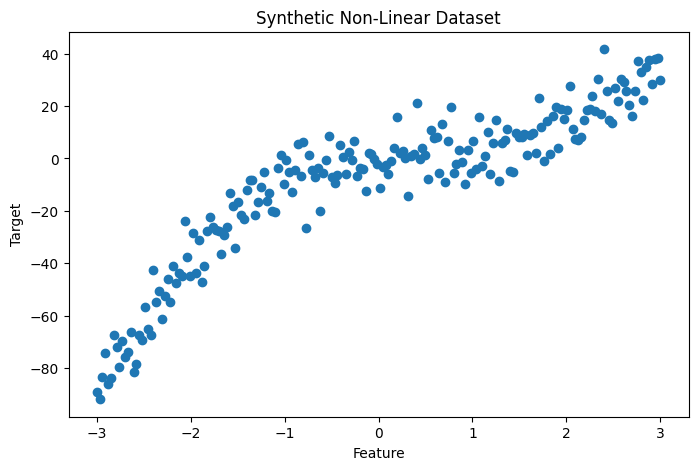

In [3]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Synthetic Non-Linear Dataset")

plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [5]:
degrees = [1, 2, 3, 10, 15]

results = []

for degree in degrees:

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree)),
        ("linear", LinearRegression())
    ])

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    results.append({
        "Degree": degree,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred)
    })

results_df = pd.DataFrame(results)

print(results_df)

   Degree   Train MSE    Test MSE  Train R2   Test R2
0       1  178.822834  197.780360  0.810695  0.683130
1       2  115.343990  107.141639  0.877895  0.828345
2       3   55.750992   50.097451  0.940981  0.919737
3      10   53.416159   51.187617  0.943453  0.917991
4      15   51.917708   50.795249  0.945039  0.918619


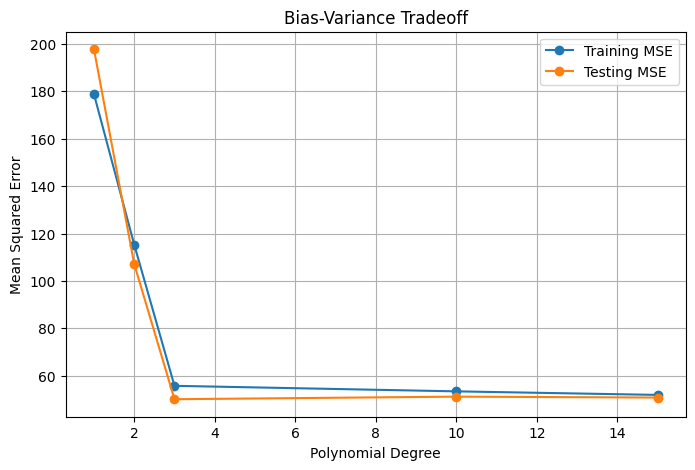

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Degree"],
    results_df["Train MSE"],
    marker="o",
    label="Training MSE"
)

plt.plot(
    results_df["Degree"],
    results_df["Test MSE"],
    marker="o",
    label="Testing MSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Bias-Variance Tradeoff")
plt.legend()
plt.grid(True)

plt.show()

In [7]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1, max_iter=10000))
    ])
}

In [8]:
regularisation_results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    regularisation_results.append({
        "Model": name,
        "Train MSE": mean_squared_error(y_train, train_pred),
        "Test MSE": mean_squared_error(y_test, test_pred),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred)
    })

regularisation_df = pd.DataFrame(regularisation_results)

print(regularisation_df)

               Model   Train MSE    Test MSE  Train R2   Test R2
0  Linear Regression  178.822834  197.780360  0.810695  0.683130
1              Ridge  178.852378  196.950712  0.810664  0.684459
2              Lasso  178.832834  197.292234  0.810685  0.683912


In [9]:
alphas = [0.01, 0.1, 1, 10, 100]

alpha_results = []

for alpha in alphas:

    ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])

    lasso = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha, max_iter=10000))
    ])

    ridge.fit(X_train, y_train)
    lasso.fit(X_train, y_train)

    ridge_pred = ridge.predict(X_test)
    lasso_pred = lasso.predict(X_test)

    alpha_results.append({
        "Alpha": alpha,
        "Ridge MSE": mean_squared_error(y_test, ridge_pred),
        "Lasso MSE": mean_squared_error(y_test, lasso_pred)
    })

alpha_df = pd.DataFrame(alpha_results)

print(alpha_df)

    Alpha   Ridge MSE   Lasso MSE
0    0.01  197.771790  197.730866
1    0.10  197.694905  197.292234
2    1.00  196.950712  193.580849
3   10.00  191.718416  223.960046
4  100.00  230.833420  640.701346


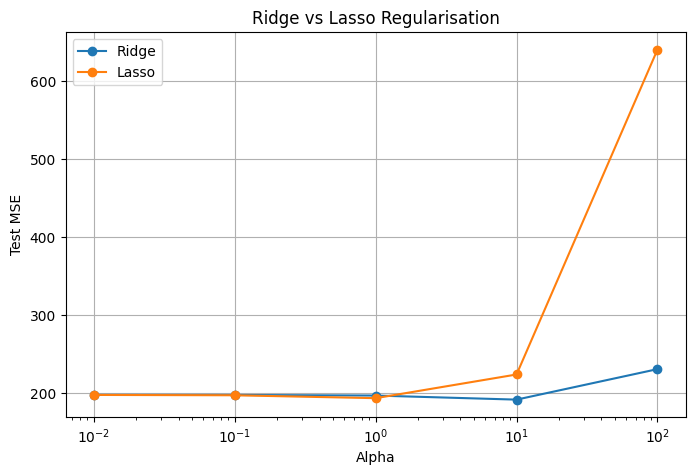

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    alpha_df["Alpha"],
    alpha_df["Ridge MSE"],
    marker="o",
    label="Ridge"
)

plt.plot(
    alpha_df["Alpha"],
    alpha_df["Lasso MSE"],
    marker="o",
    label="Lasso"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Test MSE")
plt.title("Ridge vs Lasso Regularisation")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso"
    ],
    "Test MSE": [
        regularisation_df.loc[
            regularisation_df["Model"] == "Linear Regression",
            "Test MSE"
        ].values[0],

        regularisation_df.loc[
            regularisation_df["Model"] == "Ridge",
            "Test MSE"
        ].values[0],

        regularisation_df.loc[
            regularisation_df["Model"] == "Lasso",
            "Test MSE"
        ].values[0]
    ],
    "Test R2": [
        regularisation_df.loc[
            regularisation_df["Model"] == "Linear Regression",
            "Test R2"
        ].values[0],

        regularisation_df.loc[
            regularisation_df["Model"] == "Ridge",
            "Test R2"
        ].values[0],

        regularisation_df.loc[
            regularisation_df["Model"] == "Lasso",
            "Test R2"
        ].values[0]
    ]
})

print(final_comparison)

               Model    Test MSE   Test R2
0  Linear Regression  197.780360  0.683130
1              Ridge  196.950712  0.684459
2              Lasso  197.292234  0.683912


In [12]:
print("""
=== W4D2 OBSERVATIONS ===

1. Low-complexity models can underfit the data and have high bias.
2. Very high polynomial degrees can overfit the training data.
3. Overfitting is indicated by very low training error but higher testing error.
4. Ridge regularisation reduces the effect of large model coefficients.
5. Lasso regularisation can shrink some coefficients toward zero.
6. The alpha parameter controls the strength of regularisation.
7. The best model should provide a good balance between training and testing performance.
""")


=== W4D2 OBSERVATIONS ===

1. Low-complexity models can underfit the data and have high bias.
2. Very high polynomial degrees can overfit the training data.
3. Overfitting is indicated by very low training error but higher testing error.
4. Ridge regularisation reduces the effect of large model coefficients.
5. Lasso regularisation can shrink some coefficients toward zero.
6. The alpha parameter controls the strength of regularisation.
7. The best model should provide a good balance between training and testing performance.

